In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Convert target
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

# **EDA and Data Visualization**

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

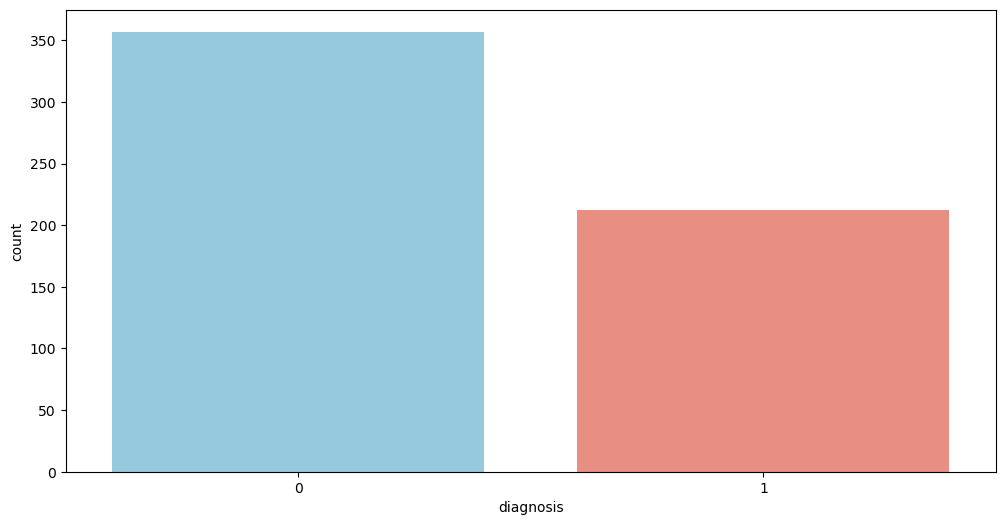

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(
    x='diagnosis',
    data=df,
    hue='diagnosis',         
    palette=['skyblue', 'salmon'],
    legend=False              
)
plt.show()

<Axes: >

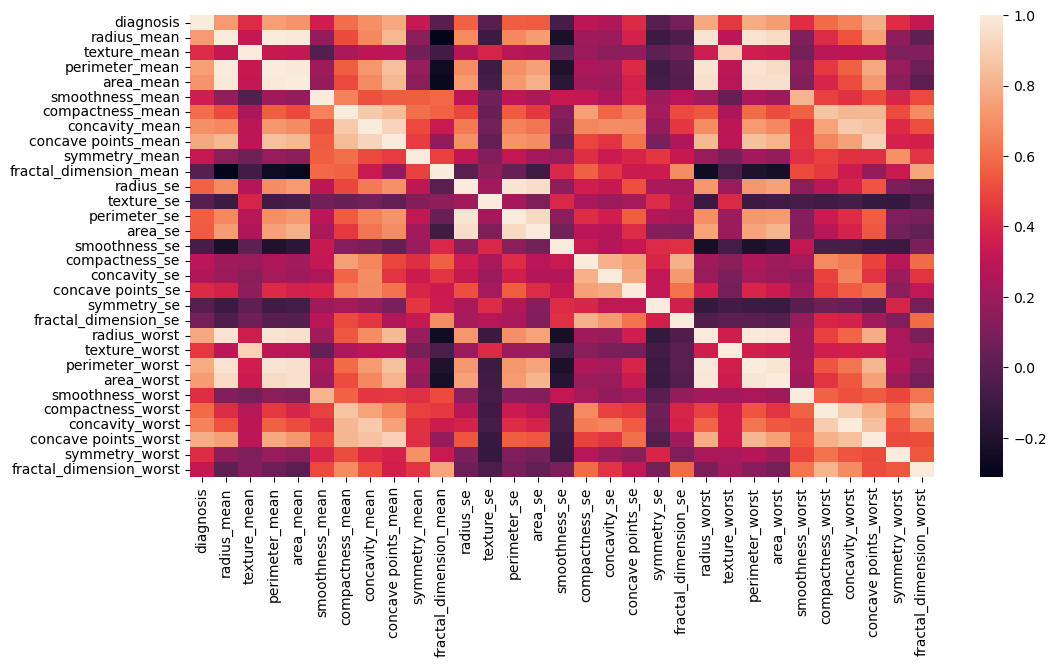

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr())

In [10]:
df.corr()['diagnosis'].sort_values()

smoothness_se             -0.067016
fractal_dimension_mean    -0.012838
texture_se                -0.008303
symmetry_se               -0.006522
fractal_dimension_se       0.077972
concavity_se               0.253730
compactness_se             0.292999
fractal_dimension_worst    0.323872
symmetry_mean              0.330499
smoothness_mean            0.358560
concave points_se          0.408042
texture_mean               0.415185
symmetry_worst             0.416294
smoothness_worst           0.421465
texture_worst              0.456903
area_se                    0.548236
perimeter_se               0.556141
radius_se                  0.567134
compactness_worst          0.590998
compactness_mean           0.596534
concavity_worst            0.659610
concavity_mean             0.696360
area_mean                  0.708984
radius_mean                0.730029
area_worst                 0.733825
perimeter_mean             0.742636
radius_worst               0.776454
concave points_mean        0

<Axes: >

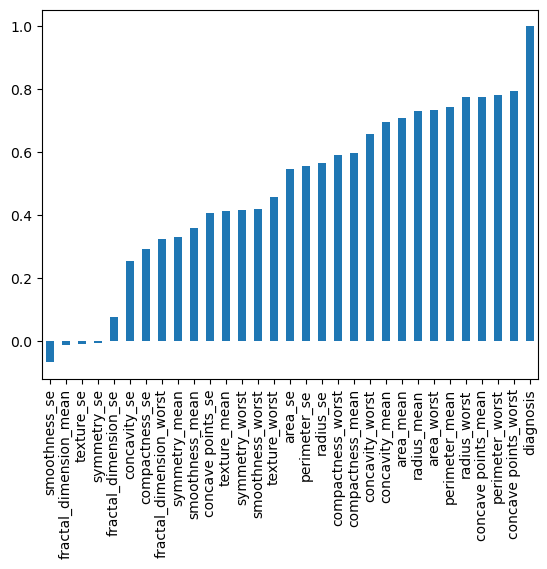

In [11]:
df.corr()['diagnosis'].sort_values().plot(kind='bar')

<Axes: >

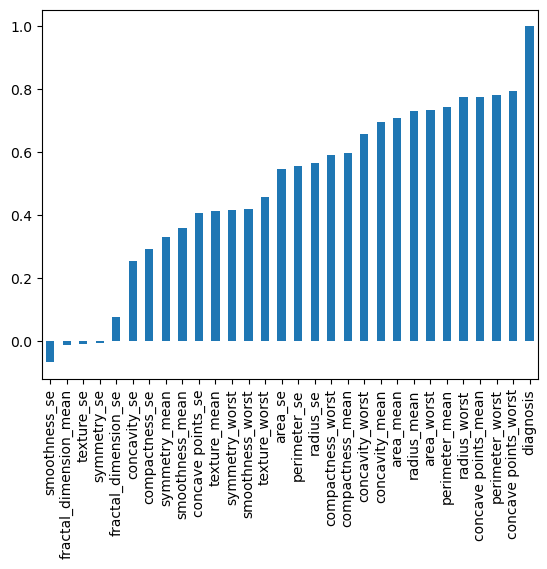

In [12]:
df.corr()['diagnosis'][:-1].sort_values().plot(kind='bar')

In [13]:
df.diagnosis.value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [14]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis'].values


# **Train Test Split**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Scaling Data**

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
accuracy=dict()

# **Logistic Regression**

In [18]:
# Reference: https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [20]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, random_state=42))
])

# Hyperparameter grid
lr_params = [
    {
        'lr__penalty': ['l2'],
        'lr__C': [0.01, 0.1, 1, 10, 100],
        'lr__solver': ['lbfgs']
    },
    {
        'lr__penalty': ['l1'],
        'lr__C': [0.01, 0.1, 1, 10],
        'lr__solver': ['liblinear']
    }
]

# Grid search with 5-fold CV
lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_params,
    cv=5,
    n_jobs=-1
)

# Fit on training data
lr_grid.fit(X_train, y_train)

# Best model
best_lr = lr_grid.best_estimator_

# Predict on test data
y_pred = best_lr.predict(X_test)

# Evaluate
print("Best Params:", lr_grid.best_params_)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Params: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[[72  0]
 [ 2 40]]
Accuracy: 0.9824561403508771


In [21]:
accuracy['Logistic Regression'] = accuracy_score(y_test, y_pred)

In [22]:
# Logistic Regression without hyperparameter optimization
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Results without hyper parameter tuning")
print("Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Results without hyper parameter tuning
Accuracy: 0.9649122807017544


In [23]:
print(accuracy)

{'Logistic Regression': 0.9824561403508771}


# **Naive Bayes**

In [24]:
from sklearn.naive_bayes import GaussianNB


In [25]:
nb = GaussianNB()

In [26]:
nb.fit(X_train, y_train)

GaussianNB()

In [27]:
y_pred = nb.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        72
           1       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

[[72  0]
 [ 7 35]]
Accuracy: 0.9385964912280702


In [28]:
accuracy['Naive Bayes'] = accuracy_score(y_test, y_pred)

In [29]:
print(accuracy)

{'Logistic Regression': 0.9824561403508771, 'Naive Bayes': 0.9385964912280702}


# **KNN**

In [30]:
# We need to first find the optimal value of K. So I do that with grid search along with cross validation.
# Reference: https://www.geeksforgeeks.org/machine-learning/how-to-find-the-optimal-value-of-k-in-knn/

In [31]:
from sklearn.neighbors import KNeighborsClassifier

In [32]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [33]:
knn_params = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

In [34]:
knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_params,
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30],
                         'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']})

In [35]:
best_knn = knn_grid.best_estimator_
print("Best Params:", knn_grid.best_params_)

Best Params: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}


In [36]:
y_pred = best_knn.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

[[72  0]
 [ 4 38]]
Accuracy: 0.9649122807017544


In [37]:
accuracy['KNN'] = accuracy_score(y_test, y_pred)

In [38]:
print(accuracy)

{'Logistic Regression': 0.9824561403508771, 'Naive Bayes': 0.9385964912280702, 'KNN': 0.9649122807017544}


# **Decision Tree**

In [39]:
from sklearn.tree import DecisionTreeClassifier

In [40]:
dt = DecisionTreeClassifier(random_state=42)
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 3, 4, 5, 6, 8, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [41]:
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 4, 5, 6, 8, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [42]:
best_dt = dt_grid.best_estimator_
print("Best Params:", dt_grid.best_params_)

Best Params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [43]:
y_pred = best_dt.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        72
           1       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

[[72  0]
 [ 7 35]]
Accuracy: 0.9385964912280702


In [44]:
accuracy['Decision Tree'] = accuracy_score(y_test, y_pred)
print(accuracy)

{'Logistic Regression': 0.9824561403508771, 'Naive Bayes': 0.9385964912280702, 'KNN': 0.9649122807017544, 'Decision Tree': 0.9385964912280702}


In [45]:
# Decision Tree without hyperparameter optimization
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9298245614035088


# **Random Forest**

In [46]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]})

In [47]:
best_rf = rf_grid.best_estimator_
print("Best Params:", rf_grid.best_params_)

Best Params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [48]:
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
accuracy['Random Forest'] = accuracy_score(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

[[72  0]
 [ 3 39]]
Accuracy: 0.9736842105263158
{'Logistic Regression': 0.9824561403508771, 'Naive Bayes': 0.9385964912280702, 'KNN': 0.9649122807017544, 'Decision Tree': 0.9385964912280702, 'Random Forest': 0.9736842105263158}


In [49]:
# Random Forest without hyper parameter optimization
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9736842105263158


# **AdaBoost**

In [50]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    algorithm="SAMME",
    random_state=42
)

ada_params = {
    "n_estimators": [25, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    estimator=ada,
    param_grid=ada_params,
    cv=5,
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)
y_pred = ada_grid.best_estimator_.predict(X_test)
print("Best Params:", ada_grid.best_params_)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
accuracy["AdaBoost"] = accuracy_score(y_test, y_pred)

Best Params: {'learning_rate': 1.0, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

[[72  0]
 [ 3 39]]
Accuracy: 0.9736842105263158


In [51]:
# Adaboost without hyper parameter optimization
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print("AdaBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred))


AdaBoost Results
Accuracy: 0.9649122807017544


/packages/envs/tensorflow-gpu-2.15.0/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [52]:
# The default AdaBoost model performs very well on this dataset because its standard parameters
# (e.g., n_estimators=50 and learning_rate=1.0) are already well-balanced for bias and variance. 
# In this case, hyperparameter tuning did not improve performance and slightly reduced test accuracy, 
# showing that the default configuration was already near-optimal for the given data.
#accuracy['AdaBoost'] = accuracy_score(y_test, y_pred)
print(accuracy)

{'Logistic Regression': 0.9824561403508771, 'Naive Bayes': 0.9385964912280702, 'KNN': 0.9649122807017544, 'Decision Tree': 0.9385964912280702, 'Random Forest': 0.9736842105263158, 'AdaBoost': 0.9736842105263158}


# **BaggingClassifier**

In [53]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

params = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0]
}
grid = GridSearchCV(bag, params, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
y_pred = grid.best_estimator_.predict(X_test)
print("Best Params:", grid.best_params_)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred))
accuracy['Bagging'] = accuracy_score(y_test, y_pred)

Best Params: {'max_samples': 1.0, 'n_estimators': 200}
Bagging Accuracy: 0.9736842105263158


In [54]:
# Bagging Classifier without hyper parameter optimization
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bag.fit(X_train, y_train)
y_pred = bag.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred))
accuracy['Bagging'] = accuracy_score(y_test, y_pred)
print(accuracy)

Bagging Accuracy: 0.9736842105263158
{'Logistic Regression': 0.9824561403508771, 'Naive Bayes': 0.9385964912280702, 'KNN': 0.9649122807017544, 'Decision Tree': 0.9385964912280702, 'Random Forest': 0.9736842105263158, 'AdaBoost': 0.9736842105263158, 'Bagging': 0.9736842105263158}


# **ANN: Creating the Model For a binary classification problem**


In [55]:
import os
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Build info:", tf.sysconfig.get_build_info())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ANN model
ann = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred_prob = ann.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Evaluate
print("ANN Results")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))



2026-05-03 16:07:53.610042: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-03 16:07:53.610117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-03 16:07:53.980919: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-03 16:07:54.414752: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.15.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Build info: OrderedDict([('cpu_compiler', '/home/conda/feedstock_root/build_artifacts/tensorflow-split_1706556017615/_build_env/bin/x86_64-conda-linux-gnu-gcc'), ('cuda_compute_capabilities', ['sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_89', 'sm_90', 'compute_90']), ('cuda_version', '12.0'), ('cudnn_version', '8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False)])


2026-05-03 16:08:09.699185: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79190 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:01:00.0, compute capability: 8.0


Epoch 1/200


2026-05-03 16:08:13.837290: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-03 16:08:19.216998: I external/local_xla/xla/service/service.cc:168] XLA service 0x15532041d720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-03 16:08:19.217041: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-05-03 16:08:19.387523: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-03 16:08:19.693725: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
I0000 00:00:1777849700.784142 4056881 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


23/23 [==============================] - 13s 9ms/step - loss: 0.5636 - accuracy: 0.7445 - val_loss: 0.4010 - val_accuracy: 0.9231
Epoch 2/200
23/23 [==============================] - 0s 3ms/step - loss: 0.3319 - accuracy: 0.9203 - val_loss: 0.2207 - val_accuracy: 0.9341
Epoch 3/200
23/23 [==============================] - 0s 3ms/step - loss: 0.1825 - accuracy: 0.9560 - val_loss: 0.1618 - val_accuracy: 0.9451
Epoch 4/200
23/23 [==============================] - 0s 3ms/step - loss: 0.1303 - accuracy: 0.9588 - val_loss: 0.1294 - val_accuracy: 0.9560
Epoch 5/200
23/23 [==============================] - 0s 3ms/step - loss: 0.0995 - accuracy: 0.9835 - val_loss: 0.1090 - val_accuracy: 0.9560
Epoch 6/200
23/23 [==============================] - 0s 3ms/step - loss: 0.0817 - accuracy: 0.9808 - val_loss: 0.1044 - val_accuracy: 0.9560
Epoch 7/200
23/23 [==============================] - 0s 3ms/step - loss: 0.0696 - accuracy: 0.9780 - val_loss: 0.0946 - val_accuracy: 0.9560
Epoch 8/200
23/23 [=====

# **Artificial Neural Network (ANN) using Stratified K-Fold Cross-Validation with Final Model Training and Test Evaluation**


In [60]:
import os
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Reproducibility
# -----------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# Convert to NumPy arrays
# -----------------------------
X_train_arr = X_train.values if hasattr(X_train, "values") else np.asarray(X_train)
X_test_arr = X_test.values if hasattr(X_test, "values") else np.asarray(X_test)
y_train_arr = np.asarray(y_train)
y_test_arr = np.asarray(y_test)

# -----------------------------
# Build ANN
# -----------------------------
def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# -----------------------------
# Folders for saving models
# -----------------------------
os.makedirs("fold_models", exist_ok=True)

# -----------------------------
# 5-Fold Stratified CV
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_histories = []
fold_val_accuracies = []
fold_test_accuracies = []
fold_val_losses = []
fold_test_probs = np.zeros(len(X_test_arr), dtype=float)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_arr, y_train_arr), 1):
    print(f"\nFold {fold}")

    # Split fold data
    X_tr = X_train_arr[train_idx]
    X_val = X_train_arr[val_idx]
    y_tr = y_train_arr[train_idx]
    y_val = y_train_arr[val_idx]

    # Scale inside fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test_arr)

    # Build fresh model
    tf.keras.backend.clear_session()
    model = build_model(X_tr_scaled.shape[1])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_tr_scaled, y_tr,
        validation_data=(X_val_scaled, y_val),
        epochs=200,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    fold_histories.append(history)
    fold_val_losses.append(history.history["val_loss"])

    # Validation accuracy for this fold
    y_val_prob = model.predict(X_val_scaled, verbose=0).ravel()
    y_val_pred = (y_val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, y_val_pred)
    fold_val_accuracies.append(val_acc)

    # Test predictions from this fold model
    y_test_prob_fold = model.predict(X_test_scaled, verbose=0).ravel()
    fold_test_probs += y_test_prob_fold

    y_test_pred_fold = (y_test_prob_fold >= 0.5).astype(int)
    test_acc = accuracy_score(y_test_arr, y_test_pred_fold)
    fold_test_accuracies.append(test_acc)

    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    print(f"Fold {fold} Test Accuracy: {test_acc:.4f}")

    # Save model and scaler
    model.save(f"fold_models/ann_fold_{fold}.keras")
    joblib.dump(scaler, f"fold_models/scaler_fold_{fold}.pkl")

# -----------------------------
# Final ensemble prediction by averaging probabilities
# -----------------------------
fold_count = skf.get_n_splits()
test_prob_avg = fold_test_probs / fold_count
y_test_pred_ensemble = (test_prob_avg >= 0.5).astype(int)

ensemble_test_acc = accuracy_score(y_test_arr, y_test_pred_ensemble)

# -----------------------------
# Results table
# -----------------------------
results_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Validation Accuracy": fold_val_accuracies,
    "Test Accuracy (Fold Model)": fold_test_accuracies
})

summary_df = pd.DataFrame({
    "Metric": [
        "Mean Validation Accuracy",
        "Std Validation Accuracy",
        "Mean Fold Test Accuracy",
        "Std Fold Test Accuracy",
        "Final Ensemble Test Accuracy"
    ],
    "Value": [
        np.mean(fold_val_accuracies),
        np.std(fold_val_accuracies),
        np.mean(fold_test_accuracies),
        np.std(fold_test_accuracies),
        ensemble_test_acc
    ]
})

print("\nPer-fold results:")
print(results_df.to_string(index=False))

print("\nSummary:")
print(summary_df.to_string(index=False))

accuracy["ANN"] = ensemble_test_acc
print("\nAccuracy dictionary:")
print(accuracy)

# -----------------------------
# Final classification report
# -----------------------------
print("\nFinal ANN Ensemble Test Results")
print(classification_report(y_test_arr, y_test_pred_ensemble))
print(confusion_matrix(y_test_arr, y_test_pred_ensemble))
print("Final Ensemble Test Accuracy:", ensemble_test_acc)




Fold 1
Fold 1 Validation Accuracy: 0.9780
Fold 1 Test Accuracy: 0.9825

Fold 2
Fold 2 Validation Accuracy: 0.9670
Fold 2 Test Accuracy: 0.9912

Fold 3
Fold 3 Validation Accuracy: 1.0000
Fold 3 Test Accuracy: 0.9825

Fold 4
Fold 4 Validation Accuracy: 0.9780
Fold 4 Test Accuracy: 0.9825

Fold 5
Fold 5 Validation Accuracy: 0.9890
Fold 5 Test Accuracy: 0.9737

Per-fold results:
 Fold  Validation Accuracy  Test Accuracy (Fold Model)
    1             0.978022                    0.982456
    2             0.967033                    0.991228
    3             1.000000                    0.982456
    4             0.978022                    0.982456
    5             0.989011                    0.973684

Summary:
                      Metric    Value
    Mean Validation Accuracy 0.982418
     Std Validation Accuracy 0.011207
     Mean Fold Test Accuracy 0.982456
      Std Fold Test Accuracy 0.005548
Final Ensemble Test Accuracy 0.982456

Accuracy dictionary:
{'Logistic Regression': 0.98245

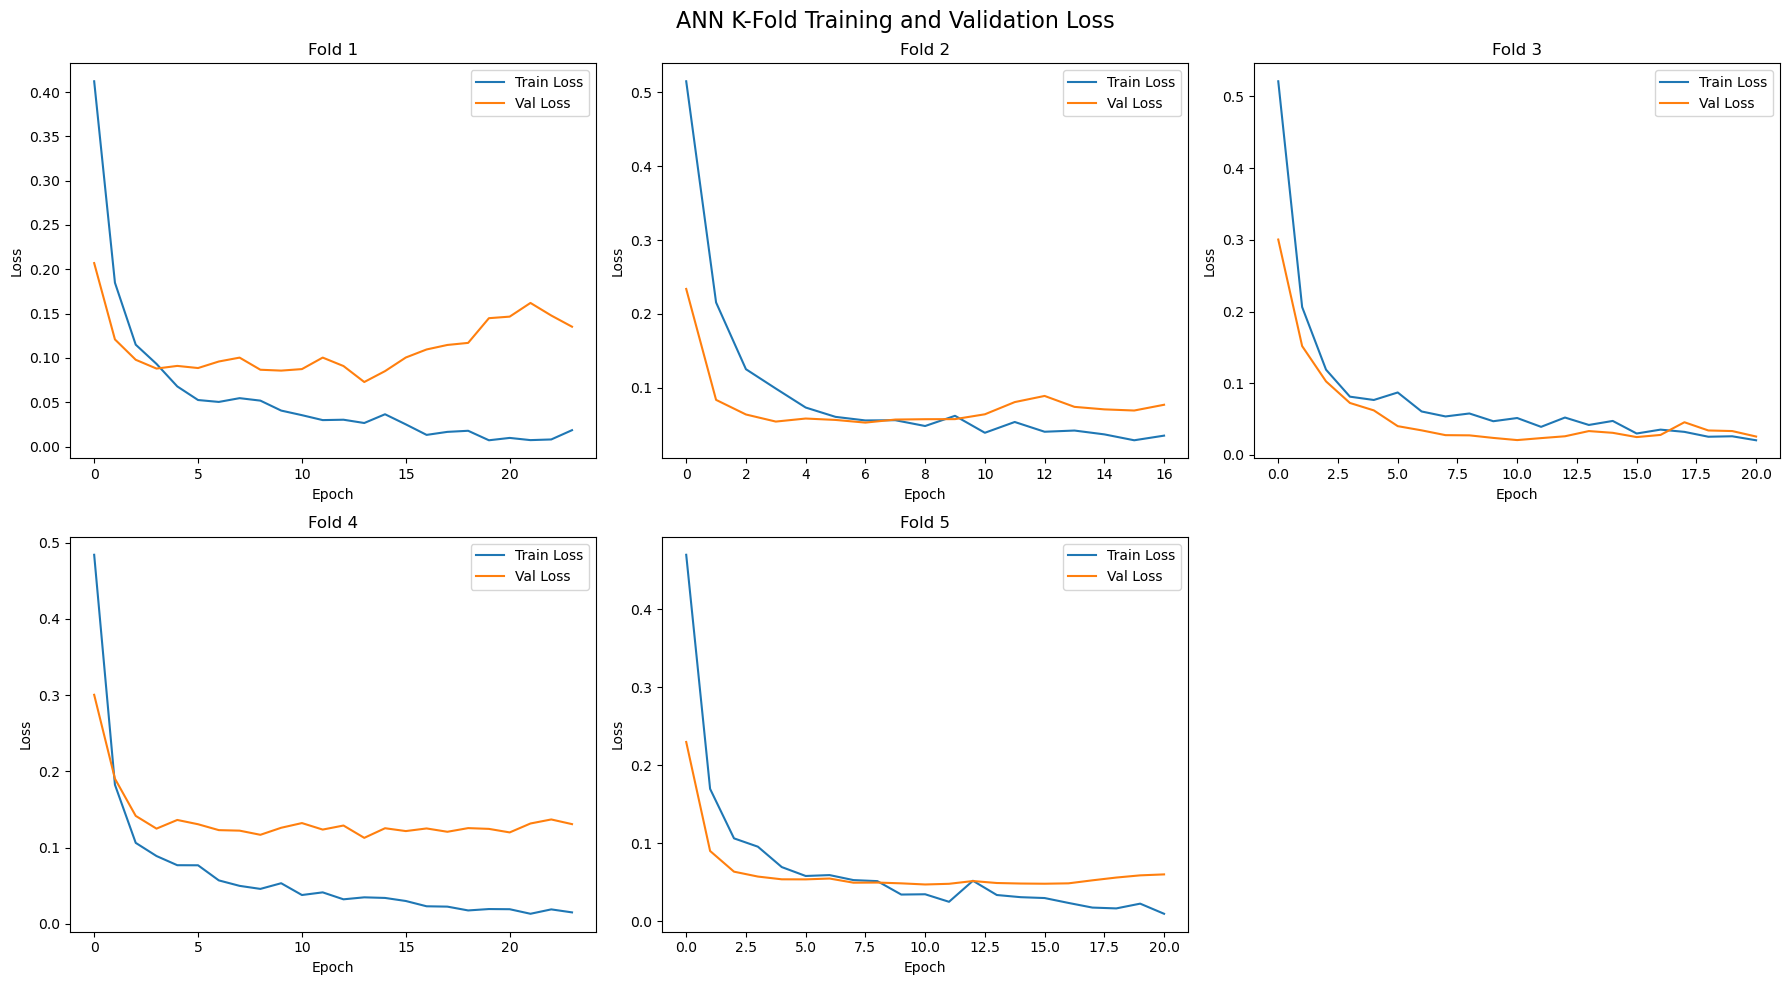

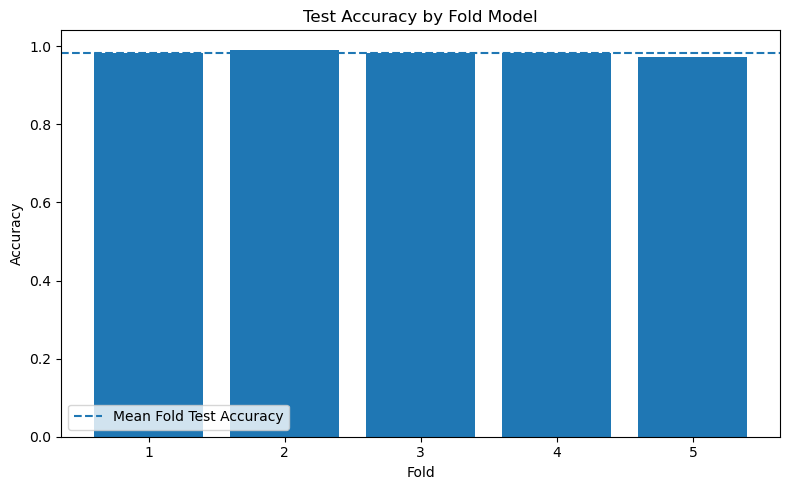

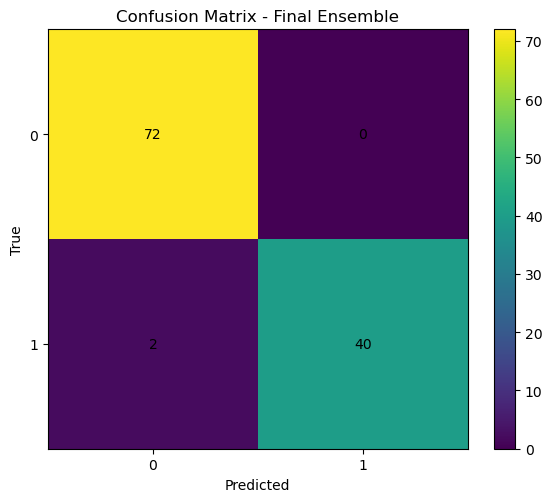

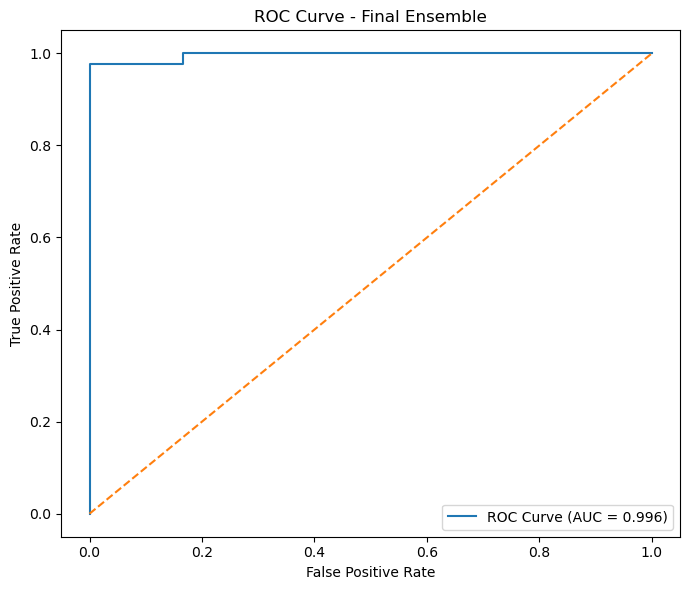

In [61]:
# -----------------------------
# Plot 1: 5 train/val loss curves in one image
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, history in enumerate(fold_histories):
    ax = axes[i]
    ax.plot(history.history["loss"], label="Train Loss")
    ax.plot(history.history["val_loss"], label="Val Loss")
    ax.set_title(f"Fold {i+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

# Hide the 6th empty subplot
axes[-1].axis("off")

plt.suptitle("ANN K-Fold Training and Validation Loss", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Fold test accuracies
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(results_df["Fold"].astype(str), results_df["Test Accuracy (Fold Model)"])
plt.axhline(np.mean(fold_test_accuracies), linestyle="--", label="Mean Fold Test Accuracy")
plt.title("Test Accuracy by Fold Model")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: Confusion matrix for ensemble test prediction
# -----------------------------
cm = confusion_matrix(y_test_arr, y_test_pred_ensemble)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - Final Ensemble")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, [0, 1])
plt.yticks(tick_marks, [0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

# -----------------------------
# Plot 4: ROC curve for ensemble
# -----------------------------
fpr, tpr, _ = roc_curve(y_test_arr, test_prob_avg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Final Ensemble")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

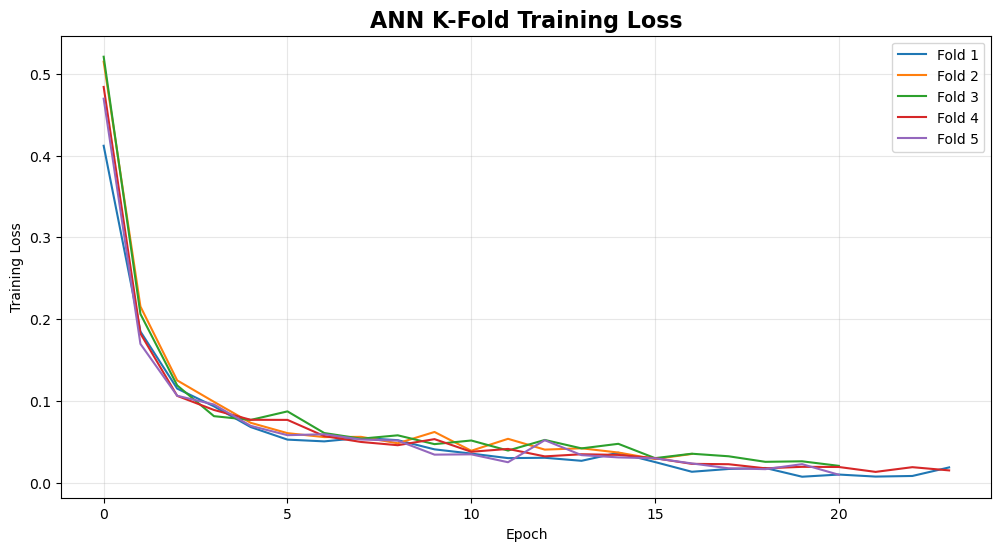

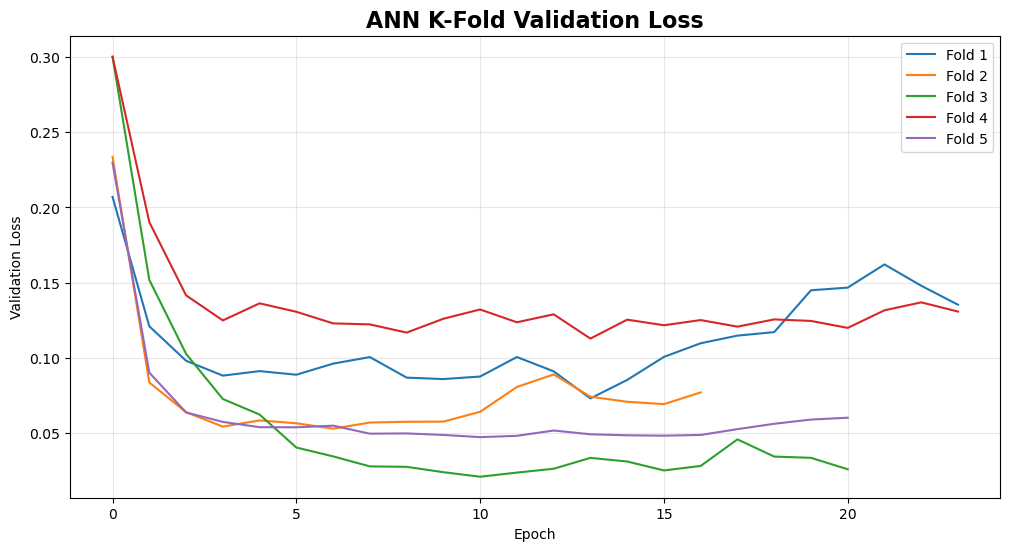

In [68]:
# -----------------------------
# ANN K-Fold Training and Validation Loss Graphs
# -----------------------------

plt.figure(figsize=(12, 6))

for i, history in enumerate(fold_histories, 1):
    plt.plot(history.history["loss"], label=f"Fold {i}")

plt.title("ANN K-Fold Training Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(12, 6))

for i, history in enumerate(fold_histories, 1):
    plt.plot(history.history["val_loss"], label=f"Fold {i}")

plt.title("ANN K-Fold Validation Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Model Accuracy Comparision**


In [63]:
print("Model Accuracy Comparison")
print("-" * 50)
print(f"{'Model':<30} {'Accuracy':<10} {'Percentage'}")
print("-" * 50)

for model_name, acc in accuracy.items():
    print(f"{model_name:<30} {acc:<10.4f} {acc * 100:.2f}%")

Model Accuracy Comparison
--------------------------------------------------
Model                          Accuracy   Percentage
--------------------------------------------------
Logistic Regression            0.9825     98.25%
Naive Bayes                    0.9386     93.86%
KNN                            0.9649     96.49%
Decision Tree                  0.9386     93.86%
Random Forest                  0.9737     97.37%
AdaBoost                       0.9737     97.37%
Bagging                        0.9737     97.37%
ANN                            0.9825     98.25%


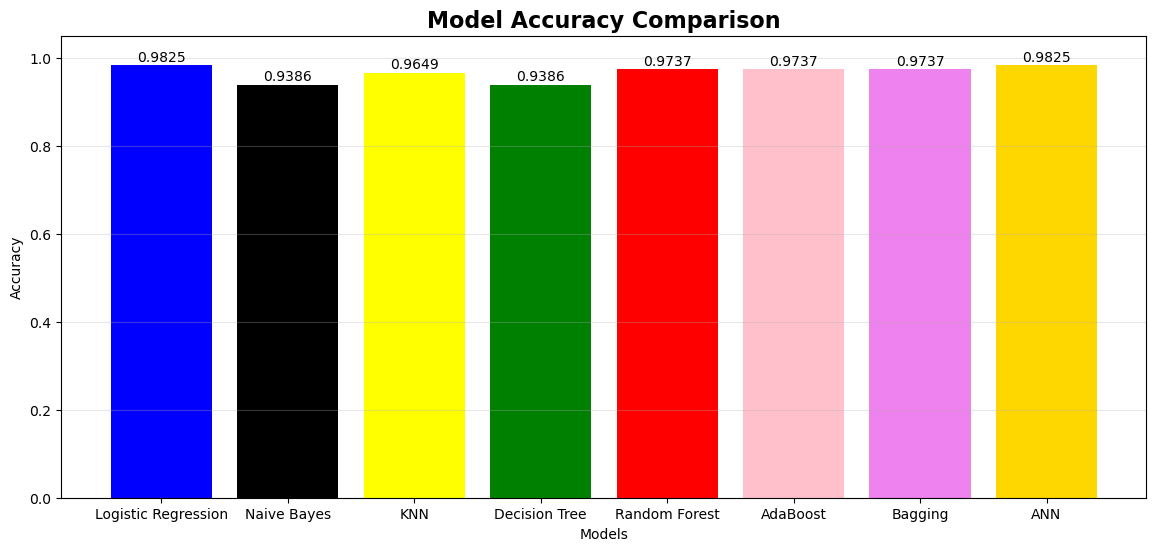

In [65]:
plt.figure(figsize=(14, 6))

colors = [
    "blue", "black", "yellow", "green",
    "red", "pink", "violet", "gold"
]

bars = plt.bar(accuracy.keys(), accuracy.values(), color=colors)

plt.title("Model Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        fontsize=10
    )

plt.show()

In [66]:
MEAN_FEATURES = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean"]

SE_FEATURES = ["radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se", "compactness_se", "concavity_se", "concave points_se", "symmetry_se", "fractal_dimension_se"]

WORST_FEATURES = ["radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst", "compactness_worst", "concavity_worst", "concave points_worst", "symmetry_worst", "fractal_dimension_worst"]

FEATURE_NAMES = MEAN_FEATURES + SE_FEATURES + WORST_FEATURES

X_test_df = pd.DataFrame(X_test, columns=FEATURE_NAMES)
y_test_series = pd.Series(y_test).reset_index(drop=True)

for i in range(5):
    actual = "Malignant" if y_test_series.iloc[i] == 1 else "Benign"

    print("\n" + "=" * 80)
    print(f"TEST SAMPLE {i + 1}")
    print(f"Actual Diagnosis: {actual}")
    print("=" * 80)

    for feature in FEATURE_NAMES:
        print(f"{feature}: {X_test_df.iloc[i][feature]}")


TEST SAMPLE 1
Actual Diagnosis: Benign
radius_mean: 11.41
texture_mean: 10.82
perimeter_mean: 73.34
area_mean: 403.3
smoothness_mean: 0.09373
compactness_mean: 0.06685
concavity_mean: 0.03512
concave points_mean: 0.02623
symmetry_mean: 0.1667
fractal_dimension_mean: 0.06113
radius_se: 0.1408
texture_se: 0.4607
perimeter_se: 1.103
area_se: 10.5
smoothness_se: 0.00604
compactness_se: 0.01529
concavity_se: 0.01514
concave points_se: 0.00646
symmetry_se: 0.01344
fractal_dimension_se: 0.002206
radius_worst: 12.82
texture_worst: 15.97
perimeter_worst: 83.74
area_worst: 510.5
smoothness_worst: 0.1548
compactness_worst: 0.239
concavity_worst: 0.2102
concave points_worst: 0.08958
symmetry_worst: 0.3016
fractal_dimension_worst: 0.08523

TEST SAMPLE 2
Actual Diagnosis: Malignant
radius_mean: 20.94
texture_mean: 23.56
perimeter_mean: 138.9
area_mean: 1364.0
smoothness_mean: 0.1007
compactness_mean: 0.1606
concavity_mean: 0.2712
concave points_mean: 0.131
symmetry_mean: 0.2205
fractal_dimension_me